# Customer Segmentation & Business Insights

**Skills demonstrated:** SQL · Python · Data Visualization · Business Analysis · Recommendation Systems

This notebook walks through an end-to-end customer analytics pipeline on a
simulated online-retail dataset (800 customers, ~8,400 orders, 25k line items,
across 6 product categories and 10 countries):

1. Data overview & business KPIs (SQL + Pandas)
2. Exploratory Data Analysis & visualizations
3. RFM (Recency, Frequency, Monetary) feature engineering
4. K-Means customer segmentation
5. Segment profiling & business recommendations
6. Product recommendation system (collaborative filtering + market basket analysis)


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("../data/online_retail_transactions.csv", parse_dates=["InvoiceDate"])
df.head()

,InvoiceNo,InvoiceDate,CustomerID,CustomerName,Country,ProductID,ProductName,Category,Quantity,UnitPrice,TotalPrice
0,INV1845,2024-05-24,C0075,Sara Patel,Germany,P0080,Body Lotion Pro,Beauty & Personal Care,5,"2,339.17","11,695.85"
1,INV7407,2024-10-04,C0603,Charlotte Nair,India,P0094,Fountain Pen Pro,Books & Stationery,5,561.98,"2,809.90"
2,INV1804,2023-06-23,C0073,Rohan Singh,India,P0099,Puzzle Book,Books & Stationery,6,290.05,"1,740.30"
3,INV2096,2024-06-01,C0090,Ananya Kumar,United Kingdom,P0097,Art Supplies Kit,Books & Stationery,6,776.04,"4,656.24"
4,INV1252,2024-09-28,C0028,Priya Patel,United States,P0109,Skipping Rope,Sports & Fitness,6,"1,096.82","6,580.92"


## 1. Business KPI Overview (via SQL)

In [2]:
conn = sqlite3.connect("../data/retail.db")

kpi = pd.read_sql('''
    SELECT
        COUNT(DISTINCT InvoiceNo)  AS total_orders,
        COUNT(DISTINCT CustomerID) AS total_customers,
        COUNT(DISTINCT ProductID)  AS total_products_sold,
        ROUND(SUM(TotalPrice), 2)  AS total_revenue,
        ROUND(AVG(TotalPrice), 2)  AS avg_line_item_value
    FROM transactions
''', conn)
kpi

,total_orders,total_customers,total_products_sold,total_revenue,avg_line_item_value
0,8400,800,120,"185,526,582.86","7,404.77"


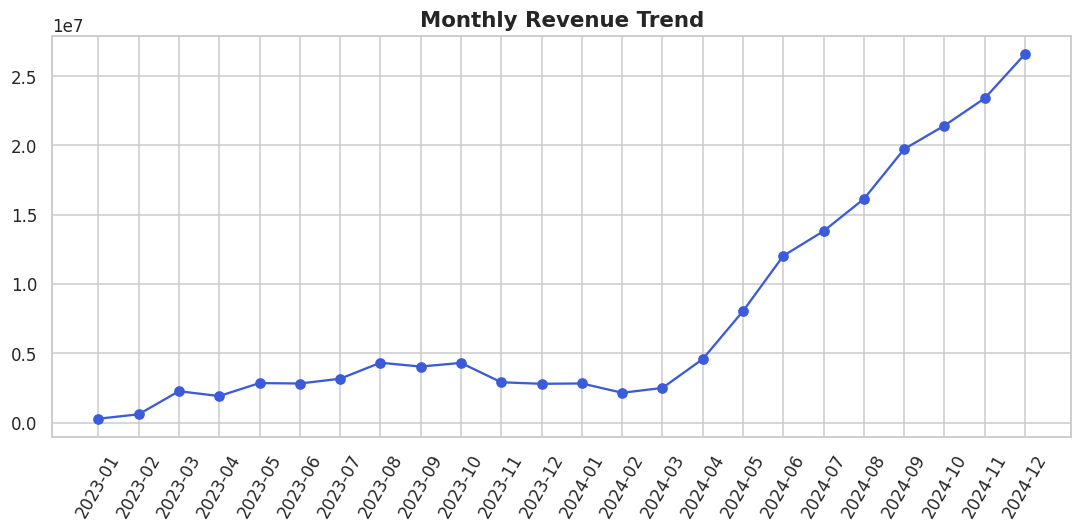

In [3]:
monthly = pd.read_sql('''
    SELECT strftime('%Y-%m', InvoiceDate) AS year_month,
           ROUND(SUM(TotalPrice), 2) AS revenue
    FROM transactions GROUP BY year_month ORDER BY year_month
''', conn)

plt.figure(figsize=(10,5))
plt.plot(monthly["year_month"], monthly["revenue"], marker="o", color="#3B5BDB")
plt.xticks(rotation=60)
plt.title("Monthly Revenue Trend", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

## 2. Exploratory Data Analysis

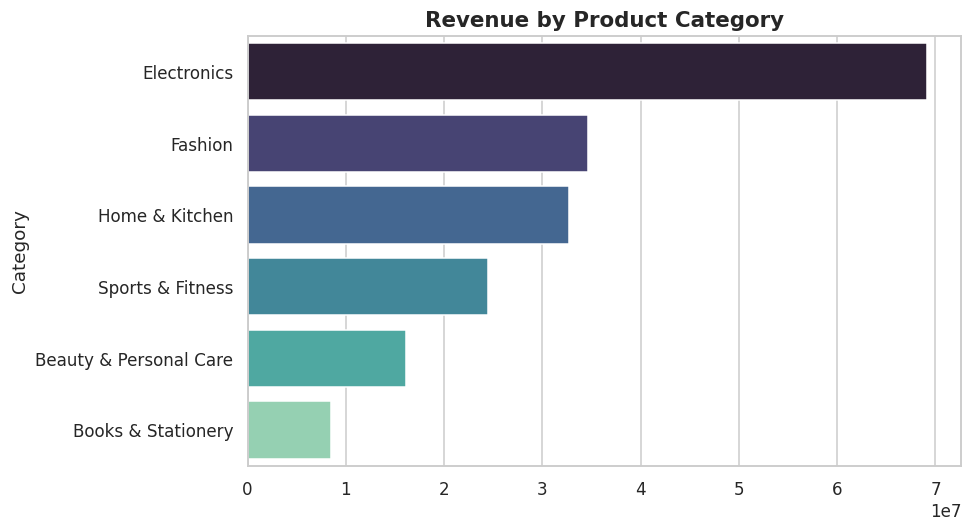

In [4]:
cat_rev = df.groupby("Category")["TotalPrice"].sum().sort_values(ascending=False)
plt.figure(figsize=(9,5))
sns.barplot(x=cat_rev.values, y=cat_rev.index, hue=cat_rev.index, legend=False, palette="mako")
plt.title("Revenue by Product Category", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

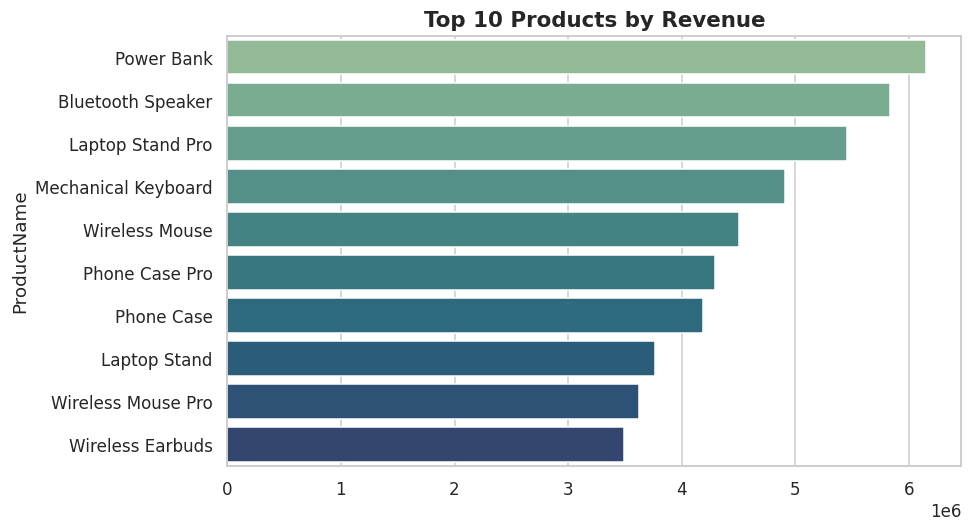

In [5]:
top_products = df.groupby("ProductName")["TotalPrice"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, legend=False, palette="crest")
plt.title("Top 10 Products by Revenue", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

## 3. RFM Feature Engineering

In [6]:
ref_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()
rfm.describe()

,Recency,Frequency,Monetary
count,800.00,800.00,800.00
mean,101.53,10.50,"231,908.23"
std,148.38,10.35,"293,128.86"
min,1.00,1.00,243.49
25%,8.00,3.00,"30,757.40"
50%,28.50,7.00,"101,425.89"
75%,126.50,16.00,"332,235.35"
max,685.00,45.00,"1,570,344.74"


## 4. K-Means Customer Segmentation

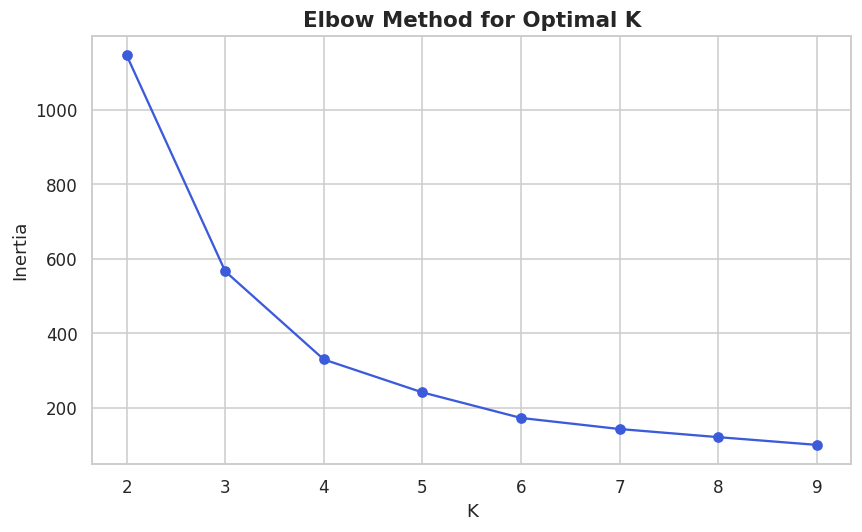

In [7]:
scaler = StandardScaler()
scaled = scaler.fit_transform(rfm[["Recency","Frequency","Monetary"]])

inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertias, marker="o", color="#3B5BDB")
plt.title("Elbow Method for Optimal K", fontsize=14, weight="bold")
plt.xlabel("K"); plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(scaled)

cluster_summary = rfm.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()
cluster_summary["RFM_Score"] = (cluster_summary["Monetary"].rank()
                                 + cluster_summary["Frequency"].rank()
                                 - cluster_summary["Recency"].rank())
ranked = cluster_summary.sort_values("RFM_Score", ascending=False).index.tolist()
names = ["Champions","Loyal Customers","Potential / At-Risk","Lost / Low-Value"]
label_map = {c: names[i] for i, c in enumerate(ranked)}
rfm["Segment"] = rfm["Cluster"].map(label_map)
cluster_summary

,Recency,Frequency,Monetary,RFM_Score
Cluster,,,,
0,13.52,17.99,"398,438.74",4.00
1,72.53,4.75,"72,553.01",1.00
2,424.77,1.80,"21,453.96",-2.00
3,5.21,34.36,"961,930.61",7.00


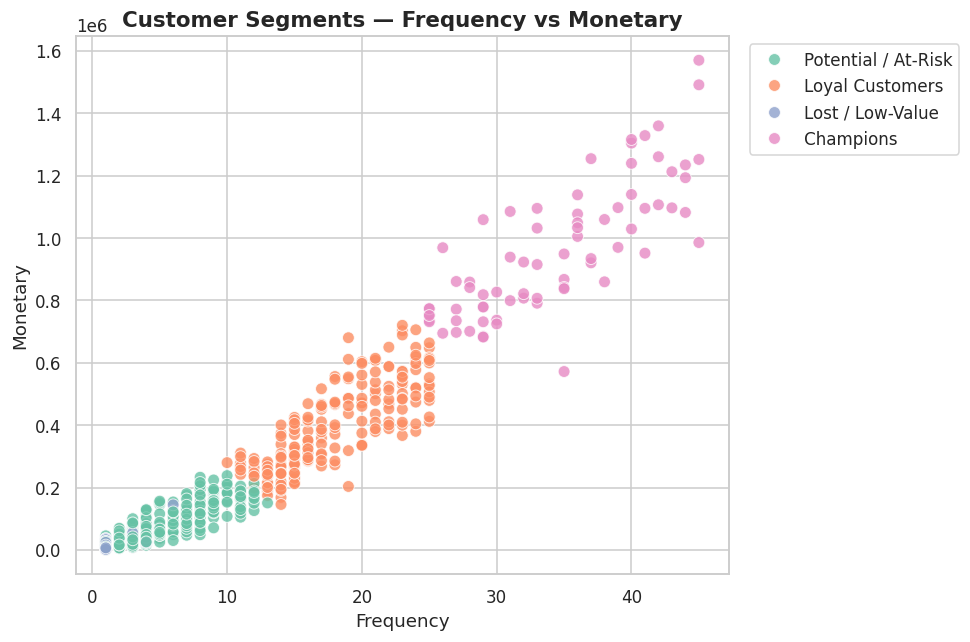

In [9]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Segment", palette="Set2", s=60, alpha=0.8)
plt.title("Customer Segments — Frequency vs Monetary", fontsize=14, weight="bold")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Segment Profiles & Business Recommendations

| Segment | Typical Profile | Suggested Business Action |
|---|---|---|
| **Champions** | Very recent, frequent, high spend | Reward with loyalty perks, early access, referral programs |
| **Loyal Customers** | Regular buyers, solid spend | Upsell/cross-sell bundles, personalized offers |
| **Potential / At-Risk** | Moderate recency & frequency | Win-back campaigns, targeted discounts, re-engagement emails |
| **Lost / Low-Value** | Long inactive, low spend | Low-cost reactivation campaigns or deprioritize marketing spend |


## 6. Recommendation System

In [10]:
purchase_matrix = df.pivot_table(index="CustomerID", columns="ProductName",
                                  values="Quantity", aggfunc="sum", fill_value=0)
item_sim = cosine_similarity(purchase_matrix.T)
item_sim_df = pd.DataFrame(item_sim, index=purchase_matrix.columns, columns=purchase_matrix.columns)

def recommend_similar_products(product_name, top_n=5):
    scores = item_sim_df[product_name].drop(index=product_name).sort_values(ascending=False)
    return scores.head(top_n)

recommend_similar_products("Air Fryer")

ProductName
Electric Kettle       0.40
Cushion Cover Set     0.40
Wall Clock Pro        0.37
Electric Kettle Pro   0.36
Knife Set             0.36
Name: Air Fryer, dtype: float64

In [11]:
association_rules_df = pd.read_csv("../data/association_rules.csv")
association_rules_df.sort_values("lift", ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
0,Cushion Cover Set Pro,LED Desk Lamp,0.00,0.16,6.81
1,LED Desk Lamp,Cushion Cover Set Pro,0.00,0.16,6.81
2,Puzzle Book,Notebook Set,0.00,0.17,6.17
3,Notebook Set,Puzzle Book,0.00,0.17,6.17
4,Smart Watch,USB-C Cable,0.00,0.15,6.17
5,USB-C Cable,Smart Watch,0.00,0.16,6.17
7,Electric Kettle Pro,Storage Boxes Pro,0.00,0.17,6.16
6,Storage Boxes Pro,Electric Kettle Pro,0.00,0.15,6.16
8,Ceramic Mug Set,Air Fryer Pro,0.00,0.16,6.10
9,Air Fryer Pro,Ceramic Mug Set,0.00,0.15,6.10


## Summary

- Built a full pipeline: **SQL** for KPI extraction -> **Python/Pandas** for RFM
  feature engineering -> **K-Means** for segmentation -> **cosine similarity /
  Apriori** for recommendations.
- Identified 4 actionable customer segments with distinct business strategies.
- Delivered a working recommendation engine usable for personalized marketing
  and cross-sell bundling.

See `README.md` for the full project write-up and `docs/` for detailed insight
summaries.
